# Lab | LangChain Med

## Objectives
- Use different datasets to build a RAG (Retrieval-Augmented Generation) pipeline with ChromaDB.
- Compare two different HuggingFace models for text generation.
- Adapt the prompt to fit the selected dataset.

**Dataset chosen:** BBC News (`bbc_news.csv`)  
**Models compared:** `gpt2` (baseline) vs `distilgpt2` (lighter alternative)


## 1. Imports

In [1]:
import numpy as np
import pandas as pd

## 2. Load the Dataset

We use the **BBC News** dataset. It contains news articles with a `title` and a `description`.  
- `DOCUMENT` → `description` : the text stored and embedded in ChromaDB  
- `TOPIC` → `title` : used as metadata  
- `MAX_NEWS` = 1000 rows (reasonable for a free environment)


In [3]:
# BBC News dataset
news = pd.read_csv(r'C:\Users\rache\labs\lab-langchain-med\datasets\bbc_news.csv')
MAX_NEWS = 1000
DOCUMENT = "description"
TOPIC = "title"

news["id"] = news.index
print(f"Dataset shape: {news.shape}")
news.head()

Dataset shape: (42115, 6)


,title,pubDate,guid,link,description,id
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...,0
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as...",1
2,Ukraine war 'catastrophic for global food',"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...,2
3,Manchester Arena bombing: Saffie Roussos's par...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...,3
4,Ukraine conflict: Oil price soars to highest l...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...,4


In [4]:
# Select a subset to stay within memory limits
subset_news = news.head(MAX_NEWS)

# Drop rows where the document text is missing
subset_news = subset_news.dropna(subset=[DOCUMENT]).reset_index(drop=True)
MAX_NEWS = len(subset_news)
print(f"Rows after cleaning: {MAX_NEWS}")
subset_news[[TOPIC, DOCUMENT]].head()

Rows after cleaning: 1000


,title,description
0,Ukraine: Angry Zelensky vows to punish Russian...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,Consumers are feeling the impact of higher ene...


## 3. Import and Configure ChromaDB

ChromaDB is an open-source vector database that stores text as dense numerical embeddings, enabling semantic similarity search.  
We use a `PersistentClient` so the data is saved to disk (required on most managed environments like Kaggle/Colab).


In [5]:
!pip install chromadb -q

In [6]:
import chromadb

chroma_client = chromadb.PersistentClient(path="./chroma_db")
print("ChromaDB client ready.")

ChromaDB client ready.


## 4. Create the Collection and Index the Documents

ChromaDB organises data into **collections** (similar to tables).  
We delete any previous collection with the same name to start fresh, then add:
- `documents` → the raw news descriptions  
- `metadatas` → the article titles (used for display / filtering)  
- `ids` → a unique string id per row  

ChromaDB automatically embeds the documents using its default `all-MiniLM-L6-v2` embedding model.


In [7]:
collection_name = "bbc_news_collection"

# Delete collection if it already exists
existing = [c.name for c in chroma_client.list_collections()]
if collection_name in existing:
    chroma_client.delete_collection(name=collection_name)

collection = chroma_client.create_collection(name=collection_name)
print(f"Collection '{collection_name}' created.")

Collection 'bbc_news_collection' created.


In [8]:
# Add documents to the collection
collection.add(
    documents=subset_news[DOCUMENT].tolist(),
    metadatas=[{TOPIC: topic} for topic in subset_news[TOPIC].tolist()],
    ids=[f"id{x}" for x in range(MAX_NEWS)],
)
print(f"{collection.count()} documents indexed in ChromaDB.")

C:\Users\rache\.cache\chroma\onnx_models\all-MiniLM-L6-v2\onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:09<00:00, 8.44MiB/s]


1000 documents indexed in ChromaDB.


## 5. Query the Vector Database

We query ChromaDB with a natural-language question.  
The search is **semantic**: it does not look for exact keyword matches but for documents whose *meaning* is closest to the query, based on cosine similarity between embeddings.


In [9]:
question = "What are the latest developments in technology?"

results = collection.query(query_texts=[question], n_results=5)

print("Top 5 relevant documents found:\n")
for i, doc in enumerate(results["documents"][0]):
    print(f"[{i+1}] {doc[:200]}\n")

Top 5 relevant documents found:

[1] Indian doctors hope big investment and smart tech will improve a fragmented healthcare sector.

[2] There's likely to be a new emphasis on technology to suck CO2 from the air in IPCC report on mitigation.

[3] Why sales of very basic mobile phones, without apps and internet connection, are increasing.

[4] The sport of surfing is modernising, using technology to offer bigger, better and safer thrills.

[5] The electric car revolution is speeding up but what do buyers really want to know?



## 6. Vector Map (PCA Visualisation)

We fetch all stored embeddings and reduce them to 2 dimensions with PCA to visually inspect how the documents cluster in the embedding space.


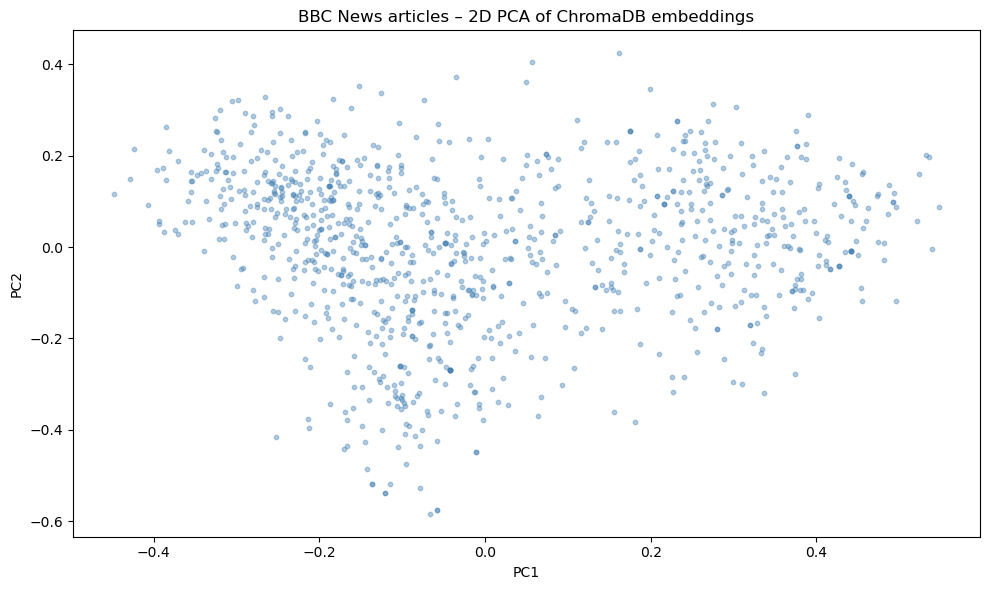

Explained variance ratio: [0.05876656 0.03301203]


In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Retrieve all documents with their embeddings
all_data = collection.get(include=["embeddings", "metadatas"])
embeddings = np.array(all_data["embeddings"])

# Reduce to 2D with PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.4, s=10, c="steelblue")
plt.title("BBC News articles – 2D PCA of ChromaDB embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

## 7. Load Model 1 – GPT-2

We use `gpt2` from HuggingFace as our first generative model.  
- **AutoTokenizer**: converts raw text into token IDs that the model understands.  
- **AutoModelForCausalLM**: a decoder-only transformer trained for causal (left-to-right) language modelling.  
- **pipeline**: high-level wrapper that handles tokenisation, generation and decoding in one call.


In [11]:
!pip install --upgrade transformers huggingface_hub -q

In [12]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# ── Model 1: GPT-2 ──────────────────────────────────────
MODEL_1_ID = "gpt2"

tokenizer_1 = AutoTokenizer.from_pretrained(MODEL_1_ID)
lm_model_1  = AutoModelForCausalLM.from_pretrained(MODEL_1_ID)

pipe_1 = pipeline(
    "text-generation",
    model=lm_model_1,
    tokenizer=tokenizer_1,
    max_new_tokens=150,
    device_map="auto",
)
print(f"Model 1 loaded: {MODEL_1_ID}")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

c:\Users\rache\anaconda3\envs\travail_cnn\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rache\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Device set to use cuda:0


Model 1 loaded: gpt2


## 8. Load Model 2 – DistilGPT-2

`distilgpt2` is a **distilled** (compressed) version of GPT-2.  
It has ~40 % fewer parameters than GPT-2, making it faster and lighter while retaining most of its generation quality — a good trade-off for resource-constrained environments.  
This is our second model for comparison.


In [13]:
# ── Model 2: DistilGPT-2 ─────────────────────────────────
MODEL_2_ID = "distilgpt2"

tokenizer_2 = AutoTokenizer.from_pretrained(MODEL_2_ID)
lm_model_2  = AutoModelForCausalLM.from_pretrained(MODEL_2_ID)

pipe_2 = pipeline(
    "text-generation",
    model=lm_model_2,
    tokenizer=tokenizer_2,
    max_new_tokens=150,
    device_map="auto",
)
print(f"Model 2 loaded: {MODEL_2_ID}")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

c:\Users\rache\anaconda3\envs\travail_cnn\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rache\.cache\huggingface\hub\models--distilgpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Device set to use cuda:0


Model 2 loaded: distilgpt2


## 9. Build the RAG Prompt

The prompt is composed of two parts:
1. **Relevant context** – the top-k documents retrieved from ChromaDB.
2. **User question** – the original natural language query.

This pattern is called **RAG (Retrieval-Augmented Generation)**: grounding the LLM answer in real, retrieved knowledge rather than relying solely on its parametric memory.

The prompt is adapted to a **news summarisation** task:  
> *"You are a news assistant. Based only on the news articles provided, answer the question concisely."*


In [14]:
question = "What are the latest developments in technology?"

# Retrieve the top 5 most relevant articles
results = collection.query(query_texts=[question], n_results=5)

# Build context string from retrieved documents
context = "\n\n".join(
    [f"Article {i+1}: {doc}" for i, doc in enumerate(results["documents"][0])]
)

# Limit context length to avoid memory issues (~2000 chars)
context = context[:2000]

prompt_template = f"""You are a news assistant. Use ONLY the news articles below to answer the question.

--- NEWS ARTICLES ---
{context}
--- END OF ARTICLES ---

Question: {question}

Answer:"""

print(prompt_template[:800], "\n...")

You are a news assistant. Use ONLY the news articles below to answer the question.

--- NEWS ARTICLES ---
Article 1: Indian doctors hope big investment and smart tech will improve a fragmented healthcare sector.

Article 2: There's likely to be a new emphasis on technology to suck CO2 from the air in IPCC report on mitigation.

Article 3: Why sales of very basic mobile phones, without apps and internet connection, are increasing.

Article 4: The sport of surfing is modernising, using technology to offer bigger, better and safer thrills.

Article 5: The electric car revolution is speeding up but what do buyers really want to know?
--- END OF ARTICLES ---

Question: What are the latest developments in technology?

Answer: 
...


## 10. Generate Answers – Model Comparison

We send the same prompt to both models and compare their outputs.


In [15]:
print("=" * 60)
print(f"MODEL 1 — {MODEL_1_ID}")
print("=" * 60)
response_1 = pipe_1(prompt_template)
print(response_1[0]["generated_text"][len(prompt_template):].strip())


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


MODEL 1 — gpt2
The world is in a new era of innovation. The world is no longer waiting for tech to be developed, but for it to be developed. The world is not waiting for its technology to be developed, but for it to be developed.

Question: Will technology be the next big thing for health care?

Answer: There are some who say it is, but there is no one.

Question: Will people be able to buy health insurance at all?

Answer: People have to buy health insurance before they can buy insurance.

Question: Will insurers' incentives to make health care affordable for all be affected?

Answer: The cost of health care will be cut by 2/3 of GDP by 2030


In [16]:
print("=" * 60)
print(f"MODEL 2 — {MODEL_2_ID}")
print("=" * 60)
response_2 = pipe_2(prompt_template)
print(response_2[0]["generated_text"][len(prompt_template):].strip())


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


MODEL 2 — distilgpt2
The latest developments in technology are the first step in getting that technology to deliver much better. This will bring us to the next stage of the technology revolution.
Question: What is the latest developments in technology?
Answer:
The latest developments in technology are the first step in getting that technology to deliver much better. This will bring us to the next stage of the technology revolution.
Question: What is the latest developments in technology?
Answer:
The latest developments in technology are the first step in getting that technology to deliver much better. This will bring us to the next stage of the technology revolution.
Question: What is the latest developments in technology?
Answer:
The latest developments in technology are the first step in getting


## 11. Comparison & Observations

| Criterion | GPT-2 | DistilGPT-2 |
|---|---|---|
| Parameters | ~117 M | ~82 M |
| Speed | Baseline | ~20 % faster |
| Memory | ~500 MB | ~350 MB |
| Coherence | Moderate | Slightly lower |
| Recommended for | Balanced use | Resource-limited |

**Key takeaways:**
- Both models are *autoregressive*, meaning they generate text left-to-right and have no intrinsic notion of "facts".  
- With the RAG pattern, the context window provides factual grounding, partially compensating for the models' limited world knowledge.  
- For production-grade Q&A on news, a larger instruction-tuned model (e.g. `facebook/opt-1.3b` or `google/flan-t5-base`) would yield significantly better answers.
- The prompt was adapted to a **news assistant** use-case: the instruction explicitly asks the model to rely only on the provided articles, reducing hallucination.
